In [57]:
#Import stuff
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

#Define functions from the lab instructions
def Skew(temp, pres):
    skew = -30
    return (temp) + skew * np.log(pres/1000)

#For below functions: temp must be in Kelvin
def dry_lapse(temp, pres):
    return (Rd*temp)/(pres*cp)

def sat_vap_pres(temp):
    c = 6.112 #hPa
    return c*np.exp(17.67*(temp-273.15)/(temp-29.65))

def rs(temp, pres):
    e_s = sat_vap_pres(temp)
    return epsilon*(e_s/(pres-e_s))

def moist_lapse(temp, pres):
    r_s = rs(temp, pres)
    numer = 1 + ((Lv*r_s)/(Rd*temp))
    denom = 1 + (((Lv**2) * r_s)/(cp*Rv*(temp**2)))
    dT_dz = -(g/cp)*numer/denom
    dT_dp = dT_dz * (Rd*temp)/(-pres*g)
    return dT_dp



#Set constants and limits from lab instructions
plines = np.arange(100, 1000, 100)
Tlines = np.arange(-100, 100, 10)
pmin, pmax = 100, 1000
Tmin, Tmax = -40, 50
epsilon = 0.622
g = 9.8
cp = 1004 #J/kgK
Rd = 287 #J/kgK
Rv = 461 #J/kgK
Lv = 2.5e6 #J/kg

#Get temps in K and flip the order of pressure for adiabat calculations
K_T = Tlines + 273.15
pres = np.arange(100,1001,1)
hPa_p = np.flip(np.arange(100, 1001, 1))

#Read in the sounding example
sounding = pd.read_csv('C:/Users/nbro9/Downloads/2026051300-72357.csv')
sounding_p = sounding['pressure_hPa']
sounding_t = sounding['temperature_C']
sounding_td = sounding['dew_point_temperature_C']


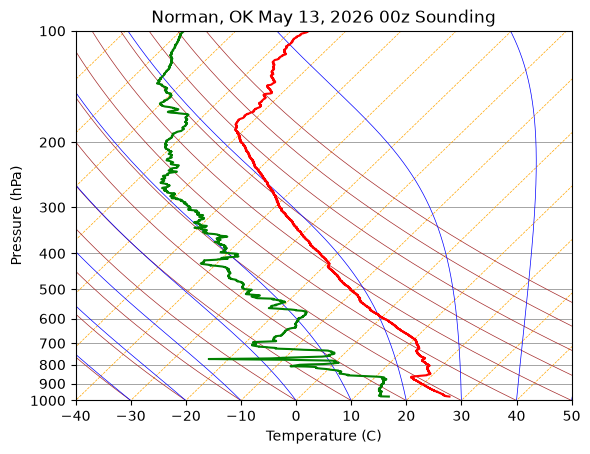

In [60]:
#Plot the skew T
fig, ax = plt.subplots()

#Plot pressure and temperature lines, formatting to lab specifications
for p in plines:
    ax.hlines(p, xmin=Tmin, xmax=Tmax, color='gray', linewidths=.5)
for T in Tlines:
    ax.plot(Skew(T, pres), np.arange(100, 1001,1), color='orange', linestyle='--', linewidth=.5)
ax.set_yscale('log') #This makes the y-axis (pressure) logarithmic
ax.set_ylim(pmax, pmin) #This sets the limits of the pressure axis provided in the lab
ax.set_xlim(Tmin, Tmax)  #This isn't working to remove the sci notation, need to find new way

#Plot the dry adiabats 
for temp in K_T:
    temps = [temp-273.15]
    t = temp
    for p in hPa_p[1:]:
        t = t - dry_lapse(t, p)
        temps.append(t-273.15)
    ax.plot(Skew(temps, hPa_p), hPa_p, color='brown', linewidth=.5)

#Plot the moist adiabats 
for temp in K_T:
    temps = [temp-273.15]
    t = temp
    for p in hPa_p[1:]:
        t = t - moist_lapse(t, p)
        temps.append(t-273.15)
    ax.plot(Skew(temps, hPa_p), hPa_p, color='blue', linewidth=.5)

#Plot sounding lines
ax.plot(Skew(sounding_t, sounding_p), sounding_p, color='red')
ax.plot(Skew(sounding_td, sounding_p), sounding_p, color='green')
ax.set_title('Norman, OK May 13, 2026 00z Sounding')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Pressure (hPa)')

#Make the y-axis not show scientific notation
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, subs=(1, 2, 3, 4, 5, 6, 7, 8, 9)))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}"))

1. The moist adiabatic lapse rate increases as a parcel ascends and cools because the air has less capacity to hold moisure. This means the moist adiabat approaches the dry adiabat as the saturation vapor pressure of the parcel decreases.

2. At a fixed pressure, the moist adabatic lapse rate increases for cooler parcels due to the same reasons in 1. The cooler parcels can hold less water and are therefore closer to the dry adiabatic lapse rate.

3. If skew values are too negative, the sounding will go off the page to the right, but if skew values are less negative or even positive, the sounding will go off the page to the left. Keep the skew values around -25 to -35 allows viewing of the whole sounding.

4. The inversion located around 850 mb is significant as it indicates the top of the boundary layer. Additionally, if considering storm potential, it indicates the cap a parcel would need to break to become positively bouyant. Another interesting feature is the transition of the enviromental lapse rate from conditionally unstable from ~700 - 450 mb to absolutely stable above this. 

5. The most challenging step in this lab was making the y-axis not plot with scientific notation (e.g. 2x10^2). I found through normal search that the logarithmic formatter was the culprit, so I implemented the fixes I found online. These did not work, leading me to eventually use GenAI to provide the fix. This can be seen in the last two lines of block 2, labeled "Make the y-axis not show scientific notation". I figure it works because it's not showing scientific notation.